<a href="https://colab.research.google.com/github/engmodu/PRactice/blob/master/Data_Analysis/DA01/%EB%8B%B9%EB%87%A8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

학습 시작...
Iteration 1 : Loss 18432.9889
Iteration 1000 : Loss 2869.3195
Iteration 2000 : Loss 2868.5687
Iteration 3000 : Loss 2868.5502
Iteration 4000 : Loss 2868.5497
Iteration 5000 : Loss 2868.5497
Iteration 6000 : Loss 2868.5497
Iteration 7000 : Loss 2868.5497
Iteration 8000 : Loss 2868.5497
Iteration 9000 : Loss 2868.5497
Iteration 10000 : Loss 2868.5497

최종 테스트 데이터 MSE: 2900.1936


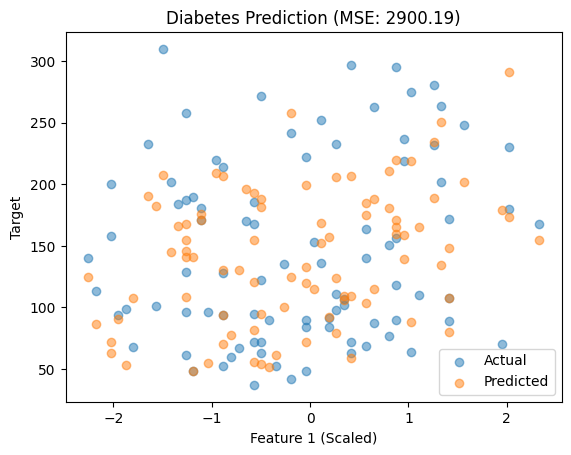

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler # [추가]

# [선택] 결과 재현을 위해 랜덤 시드 고정
np.random.seed(42)

# 1. 데이터 로드 및 전처리
data = load_diabetes()
X = data.data
y = data.target

# *** [핵심 수정] 데이터 스케일링 (표준화) ***
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 스케일링된 데이터를 사용하여 학습/테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# 2. 모델 초기화
W = np.random.rand(X_train.shape[1])
b = np.random.rand()

# 3. 모델 정의
def model(X, W, b):
    # 벡터 연산으로 변경하여 속도 향상 (선택사항이지만 권장)
    return X.dot(W) + b

# 4. 손실 함수 (MSE) 정의
def MSE(a, b):
    return ((a - b) ** 2).mean()

def loss(X, W, b, y):
    predictions = model(X, W, b)
    return MSE(predictions, y)

# 5. 경사 계산 함수 정의
def gradient(X, W, b, y):
    N = len(y)
    y_pred = model(X, W, b)
    dW = 1/N * 2 * X.T.dot(y_pred - y)
    db = 2 * (y_pred - y).mean()
    return dW, db

# 6. 하이퍼파라미터 설정
# *** [수정] 학습률과 반복 횟수 최적화 ***
LEARNING_RATE = 0.1  # 스케일링 후 적절히 높은 값
EPOCHS = 10000       # 충분히 많이 학습

# 7. 모델 학습 (경사 하강법)
losses = []

print("학습 시작...")
for i in range(1, EPOCHS + 1):
    dW, db = gradient(X_train, W, b, y_train)
    W -= LEARNING_RATE * dW
    b -= LEARNING_RATE * db

    # 매번 손실을 계산하면 느리므로 출력할 때만 계산 (선택사항)
    if i % 1000 == 0 or i == 1:
        L = loss(X_train, W, b, y_train)
        losses.append(L)
        print('Iteration %d : Loss %0.4f' % (i, L))

# 8. 모델 평가
prediction_test = model(X_test, W, b)
final_test_loss = MSE(prediction_test, y_test)
#print(f"\n최종 테스트 데이터 MSE: {final_test_loss .4f}")
print(f"\n최종 테스트 데이터 MSE: {final_test_loss:.4f}") # %를 :.으로 고쳤습니다.

# 결과 시각화
plt.scatter(X_test[:, 0], y_test, label='Actual', alpha=0.5)
plt.scatter(X_test[:, 0], prediction_test, label='Predicted', alpha=0.5)
plt.xlabel('Feature 1 (Scaled)')
plt.ylabel('Target')
plt.title(f'Diabetes Prediction (MSE: {final_test_loss:.2f})')
plt.legend()
plt.show()